Extra Trees (Extremely Randomized Trees) vs Random Forest on the same wine dataset. The difference: Random Forest picks the *best* split threshold per feature; Extra Trees picks a *random* threshold and just chooses the best of those random splits.

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report

wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [2]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
et = ExtraTreesClassifier(n_estimators=200, random_state=42)

t0 = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - t0

t0 = time.time()
et.fit(X_train, y_train)
et_time = time.time() - t0

print(f"Random Forest -> test acc: {rf.score(X_test, y_test)*100:.2f}%, fit time: {rf_time:.4f}s")
print(f"Extra Trees   -> test acc: {et.score(X_test, y_test)*100:.2f}%, fit time: {et_time:.4f}s")

Random Forest -> test acc: 100.00%, fit time: 0.1102s
Extra Trees   -> test acc: 100.00%, fit time: 0.0776s


Random Forest CV accuracy: 96.65% (+/- 2.07%)
Extra Trees   CV accuracy: 96.65% (+/- 2.07%)


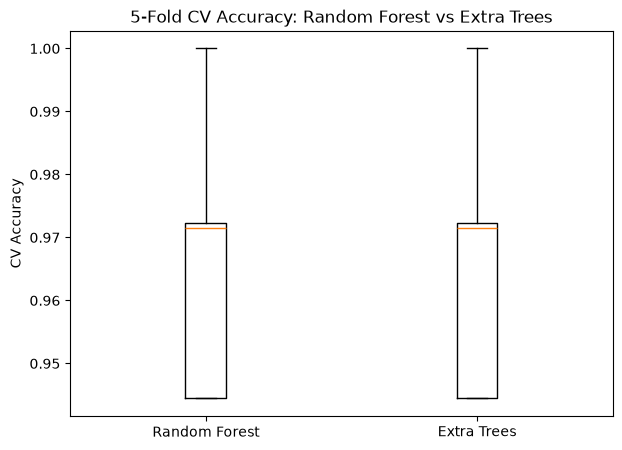

In [3]:
# Cross-validated comparison (more reliable than a single train/test split)
rf_scores = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42), X, y, cv=5)
et_scores = cross_val_score(ExtraTreesClassifier(n_estimators=200, random_state=42), X, y, cv=5)

print(f"Random Forest CV accuracy: {rf_scores.mean()*100:.2f}% (+/- {rf_scores.std()*100:.2f}%)")
print(f"Extra Trees   CV accuracy: {et_scores.mean()*100:.2f}% (+/- {et_scores.std()*100:.2f}%)")

plt.figure(figsize=(7, 5))
plt.boxplot([rf_scores, et_scores], tick_labels=['Random Forest', 'Extra Trees'])
plt.ylabel('CV Accuracy')
plt.title('5-Fold CV Accuracy: Random Forest vs Extra Trees')
plt.show()

In [4]:
# Bias-variance angle: Extra Trees' extra randomness usually means
# higher bias per tree but lower variance for the ensemble. Check variance
# across different random seeds (simulating "different runs").
seeds = range(10)
rf_accs = []
et_accs = []
for s in seeds:
    rf_s = RandomForestClassifier(n_estimators=50, random_state=s)
    et_s = ExtraTreesClassifier(n_estimators=50, random_state=s)
    rf_s.fit(X_train, y_train)
    et_s.fit(X_train, y_train)
    rf_accs.append(rf_s.score(X_test, y_test))
    et_accs.append(et_s.score(X_test, y_test))

print(f"Random Forest across seeds -> mean: {np.mean(rf_accs)*100:.2f}%, std: {np.std(rf_accs)*100:.2f}%")
print(f"Extra Trees across seeds   -> mean: {np.mean(et_accs)*100:.2f}%, std: {np.std(et_accs)*100:.2f}%")

Random Forest across seeds -> mean: 99.07%, std: 1.24%
Extra Trees across seeds   -> mean: 99.07%, std: 1.24%


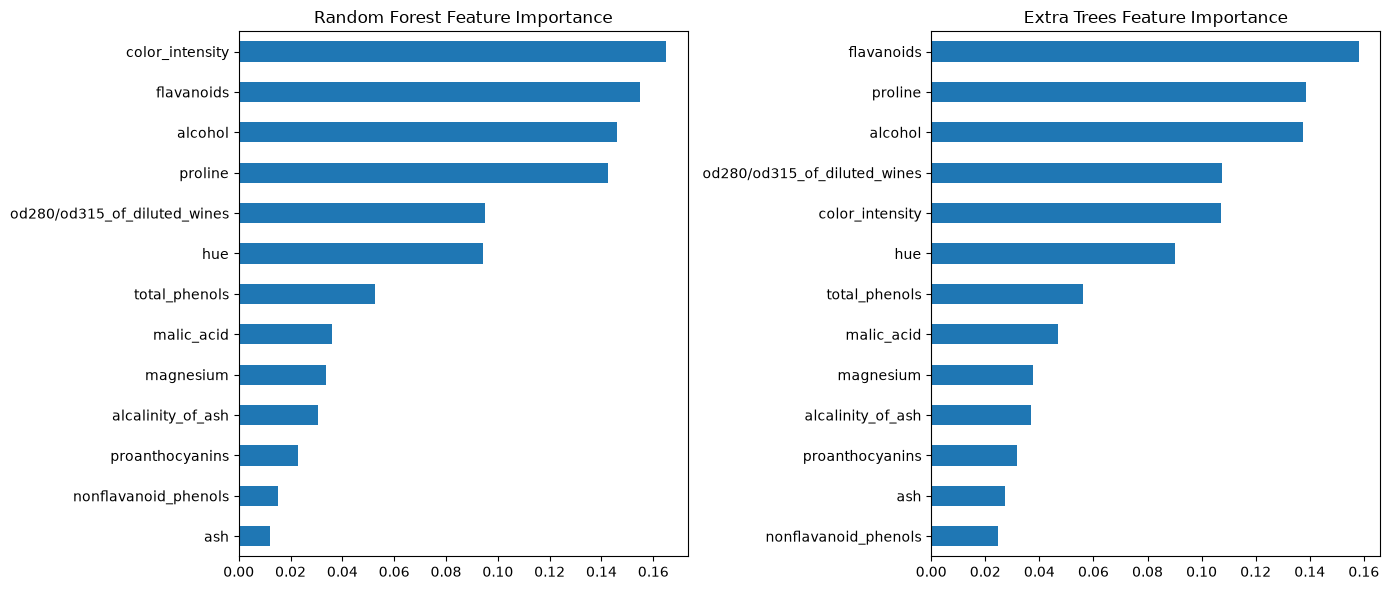

In [5]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
et_imp = pd.Series(et.feature_importances_, index=feature_names).sort_values()

rf_imp.plot.barh(ax=axes[0], title='Random Forest Feature Importance')
et_imp.plot.barh(ax=axes[1], title='Extra Trees Feature Importance')
plt.tight_layout()
plt.show()